In [105]:
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
from shapely.geometry import box

In [106]:
DATA = Path("../data")

BLACK_BELT = DATA / "processed/black_belt_al_ms_dissolved.geojson"
PALEOMAP_CS_DIR = DATA / "raw/geology/paleomap/CS"
PALEOMAP_CM_DIR = DATA / "raw/geology/paleomap/CM"

DISPLAY_CRS = "EPSG:4326"
YEAR = 65

In [107]:
def clip_to_lonlat_box(
    gdf: gpd.GeoDataFrame,
    xmin: float,
    ymin: float,
    xmax: float,
    ymax: float,
) -> gpd.GeoDataFrame:
    if gdf.crs is None:
        raise ValueError("GeoDataFrame has no CRS.")
    if gdf.crs.to_string() != "EPSG:4326":
        gdf = gdf.to_crs("EPSG:4326")

    bbox = gpd.GeoDataFrame(
        geometry=[box(xmin, ymin, xmax, ymax)],
        crs="EPSG:4326",
    )
    return gdf.clip(bbox)

In [108]:
SE_BBOX = {
    "xmin": -100.0,
    "ymin": 24.0,
    "xmax": -74.0,
    "ymax": 38.5,
}

In [109]:
black_belt = gpd.read_file(BLACK_BELT).to_crs(DISPLAY_CRS)
black_belt

,name,geometry
0,Black Belt geology,"MULTIPOLYGON (((-88.34017 32.92368, -88.33819 ..."


In [110]:
cs = gpd.read_file(PALEOMAP_CS_DIR / f"{YEAR}Ma_CS_v7.shp").to_crs(DISPLAY_CRS)
cm = gpd.read_file(PALEOMAP_CM_DIR / f"{YEAR}Ma_CM_v7.shp").to_crs(DISPLAY_CRS)

print("CS shape:", cs.shape)
print("CM shape:", cm.shape)

CS shape: (46, 17)
CM shape: (90, 17)


In [111]:
cs_clip = clip_to_lonlat_box(cs, **SE_BBOX)
cm_clip = clip_to_lonlat_box(cm, **SE_BBOX)

print("CS clipped:", cs_clip.shape)
print("CM clipped:", cm_clip.shape)

CS clipped: (1, 17)
CM clipped: (1, 17)


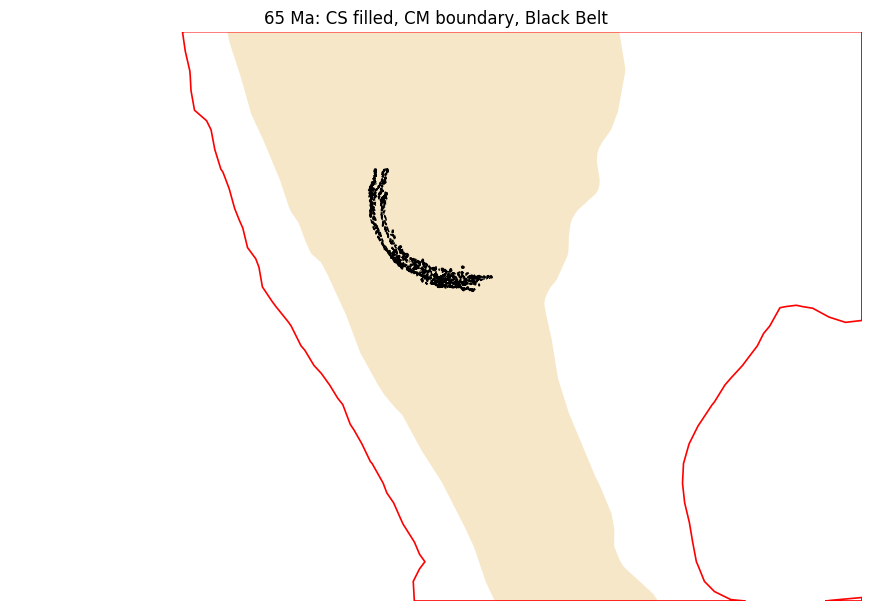

In [112]:
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

cs_clip.plot(
    ax=ax,
    color="wheat",
    edgecolor="none",
    alpha=0.7,
    label="CS polygon"
)

cm_clip.boundary.plot(
    ax=ax,
    color="red",
    linewidth=1.2,
    label="CM boundary"
)

black_belt.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.2,
    linestyle="--",
    label="Black Belt"
)

ax.set_xlim(SE_BBOX["xmin"], SE_BBOX["xmax"])
ax.set_ylim(SE_BBOX["ymin"], SE_BBOX["ymax"])

ax.set_title(f"{YEAR} Ma: CS filled, CM boundary, Black Belt")
ax.set_axis_off()
plt.show()

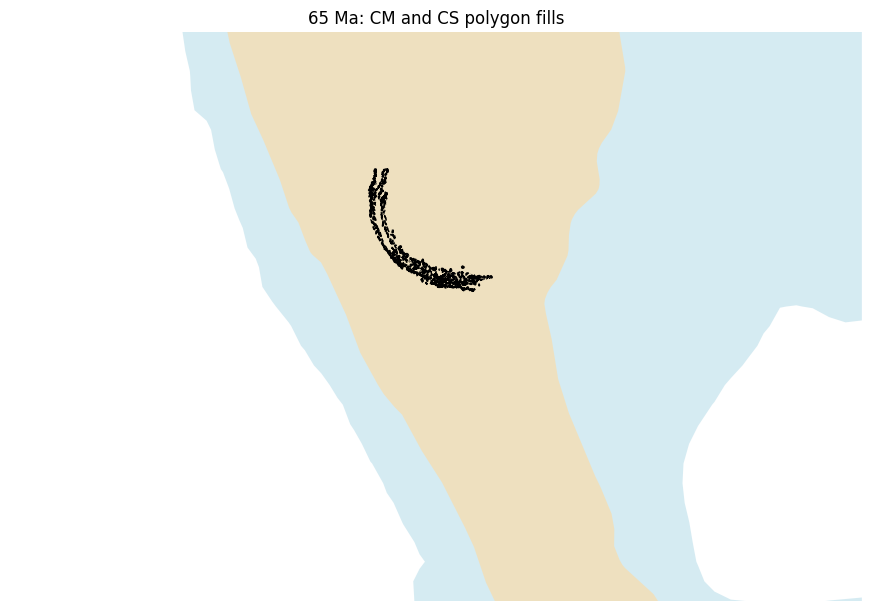

In [113]:
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

cm_clip.plot(
    ax=ax,
    color="lightblue",
    edgecolor="none",
    alpha=0.5,
    label="CM polygon"
)

cs_clip.plot(
    ax=ax,
    color="wheat",
    edgecolor="none",
    alpha=0.8,
    label="CS polygon"
)

black_belt.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.2,
    linestyle="--"
)

ax.set_xlim(SE_BBOX["xmin"], SE_BBOX["xmax"])
ax.set_ylim(SE_BBOX["ymin"], SE_BBOX["ymax"])

ax.set_title(f"{YEAR} Ma: CM and CS polygon fills")
ax.set_axis_off()
plt.show()

In [114]:
cs_union = cs_clip.union_all()
cm_union = cm_clip.union_all()

print(type(cs_union))
print(type(cm_union))

<class 'shapely.geometry.polygon.Polygon'>
<class 'shapely.geometry.multipolygon.MultiPolygon'>


In [115]:
band_geom = cm_union.difference(cs_union)

band = gpd.GeoDataFrame(
    geometry=[band_geom],
    crs=DISPLAY_CRS,
)

band

,geometry
0,"MULTIPOLYGON (((-74 24, -75.11556 24, -74.9369..."


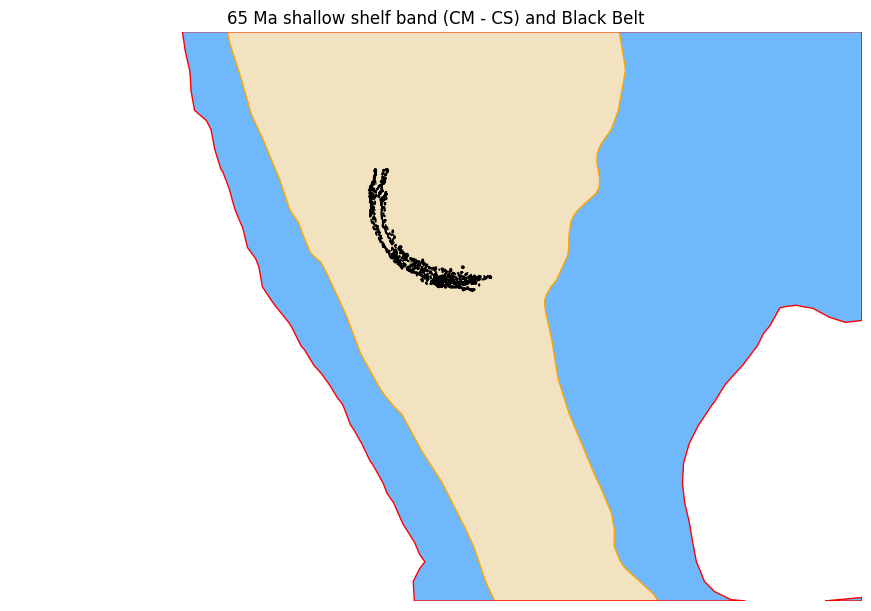

In [116]:
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

# CM background
cm_clip.plot(
    ax=ax,
    color="lightblue",
    edgecolor="none",
    alpha=0.25,
)

# shelf band
band.plot(
    ax=ax,
    color="dodgerblue",
    edgecolor="none",
    alpha=0.6,
)

# CS land/shore polygon
cs_clip.plot(
    ax=ax,
    color="wheat",
    edgecolor="none",
    alpha=0.8,
)

# outlines
cs_clip.boundary.plot(ax=ax, color="orange", linewidth=1.0)
cm_clip.boundary.plot(ax=ax, color="red", linewidth=1.0)

black_belt.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.3,
    linestyle="--"
)

ax.set_xlim(SE_BBOX["xmin"], SE_BBOX["xmax"])
ax.set_ylim(SE_BBOX["ymin"], SE_BBOX["ymax"])

ax.set_title(f"{YEAR} Ma shallow shelf band (CM - CS) and Black Belt")
ax.set_axis_off()
plt.show()